# Guide and reading the machine learning concept
<h2> Content </h2>

- practical and reading of the machine learning book

<h3> Traning and running a linear model using Scikit-learn </h3>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
import tarfile 
import urllib.request
from sklearn.linear_model import LinearRegression

In [2]:
lifestat = pd.read_csv('/Users/briankimanzi/Documents/programming Languages/PythonProgramming/JupyterNoteBook/Datasets/lifesat.csv')
x = lifestat[['GDP per capita (USD)']].values
y = lifestat[['Life satisfaction']].values

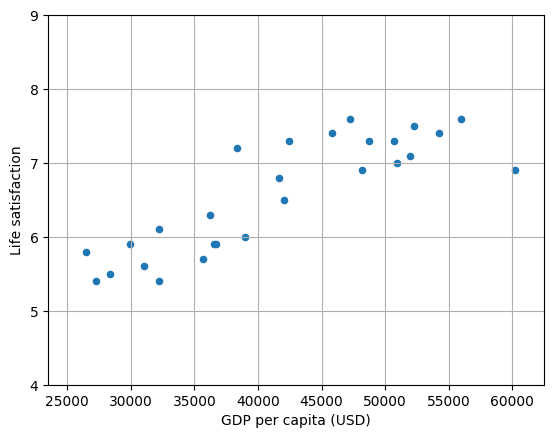

In [3]:
# visualizing the data set
lifestat.plot(kind='scatter', grid=True, 
             x = "GDP per capita (USD)", y = "Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.show()

In [4]:
# model a linear model
model = LinearRegression()
# training the model
model.fit(x, y)

LinearRegression()

In [5]:
# make prediction 
x_new  = [[37_655.2]]
model.predict(x_new)

array([[6.30165767]])

In [6]:
# using k-nearest Neighbor
from sklearn.neighbors import KNeighborsRegressor
model = KNeighborsRegressor(n_neighbors=5)
model.fit(x,y)

KNeighborsRegressor()

In [7]:
model.predict(x_new)

array([[6.26]])

In [8]:
# function to fetch and load dataset (house price)
def load_housing_data():
    tarball_path = Path('/Users/briankimanzi/Documents/programming Languages/PythonProgramming/JupyterNoteBook/Datasets/housing/housing.csv')
    csv_path = Path('/Users/briankimanzi/Documents/programming Languages/PythonProgramming/JupyterNoteBook/Datasets/housing/housing.csv')
    
    if not csv_path.is_file():
        if not tarball_path.is_file():
            Path('Datasets').mkdir(parents=True, exist_ok=True)
            url = "https://github.com/ageron/data/raw/main/housing.tgz"
            urllib.request.urlretrieve(url, tarball_path)
                
        with tarfile.open(tarball_path) as housing_tarball:
            housing_tarball.extractall(path="Datasets")
                    
    return pd.read_csv(csv_path)
        
housing = load_housing_data()

In [48]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [9]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [10]:
housing['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

In [11]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


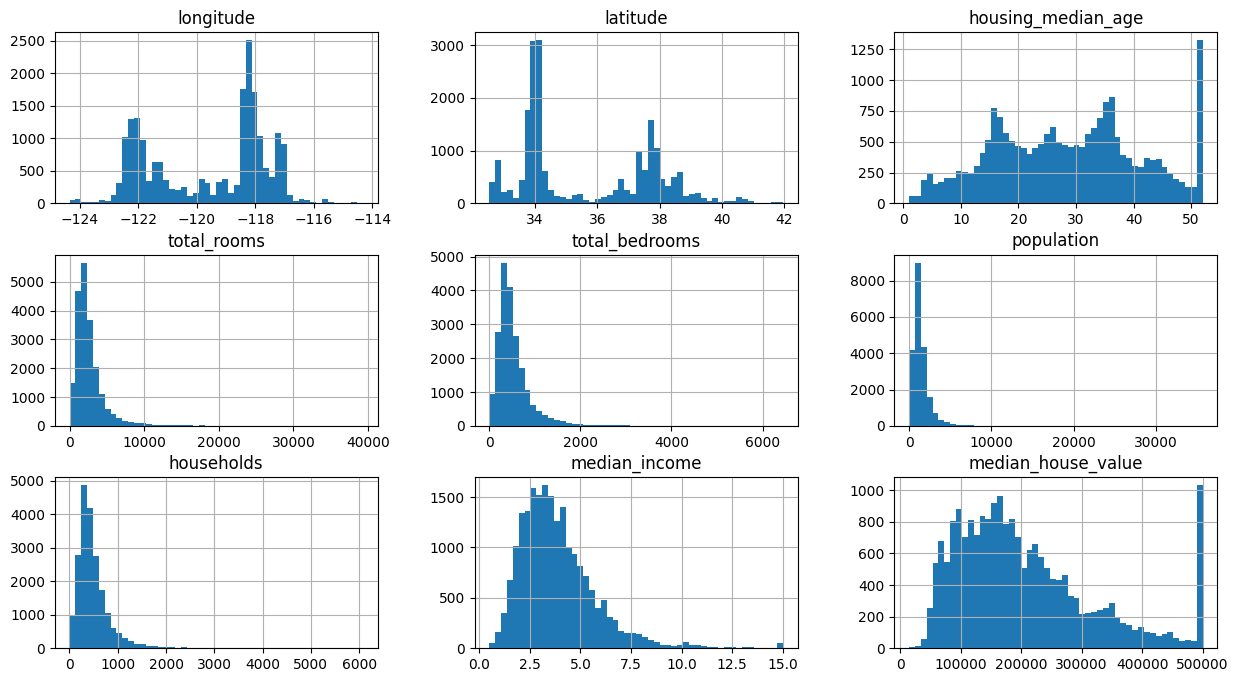

In [12]:
import matplotlib.pyplot as plt
housing.hist(bins=50, figsize=(15, 8))
plt.show()

In [13]:
# creating a test set of random values
def shuffle_and_split_data(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data) * test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices = shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [14]:
# using sklearn inbuild split and training function
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(housing, test_size=0.2, random_state=42)

In [15]:
train_set, test_set = shuffle_and_split_data(housing, 0.2)
len(train_set)

16512

In [16]:
len(test_set)

4128

In [17]:
from zlib import crc32

def is_id_in_test_set(identifier, test_ratio):
    return crc32(np.int64(identifier))< test_ratio * 2 **32

def split_data_with_id_hash(data, test_ratio, id_column):
    ids = data[id_column]
    in_test_set = ids.apply(lambda id_: is_id_in_test_set(id_, test_ratio))
    return data.loc[~in_test_set], data.loc[in_test_set]

In [18]:
housing_with_id = housing.reset_index()

In [19]:
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "index")

In [20]:
housing_with_id['id'] = housing['longitude'] * 1000 + housing['latitude']
train_set, test_set = split_data_with_id_hash(housing_with_id, 0.2, "id")

In [21]:
# creating a categorical columns on the dataset
housing["income_cat"] = pd.cut(housing["median_income"],
                              bins=[0., 1.5, 3.0, 4.5, 6., np.inf],
                              labels = [1,2,3,4,5])

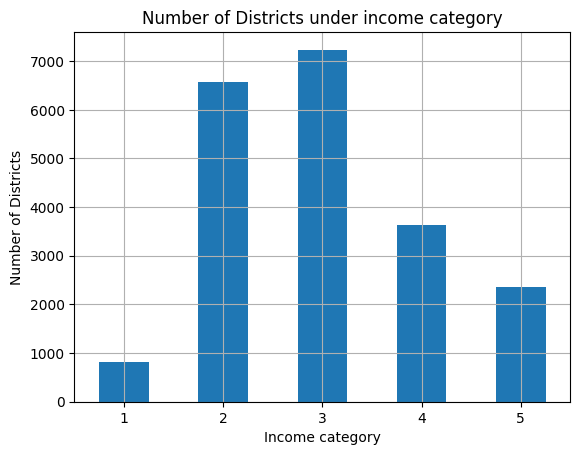

In [22]:
housing['income_cat'].value_counts().sort_index().plot.bar(rot=0, grid=True)
plt.title("Number of Districts under income category")
plt.xlabel("Income category")
plt.ylabel("Number of Districts")
plt.show()

In [24]:
# spliting the data
strat_train_set, strat_test_set = train_test_split(housing, test_size=.2, stratify=housing["income_cat"], random_state=42)

In [25]:
strat_test_set['income_cat'].value_counts() / len(strat_test_set)

income_cat
3    0.350533
2    0.318798
4    0.176357
5    0.114341
1    0.039971
Name: count, dtype: float64

In [28]:
# dropping unnecessary columns
for set_ in (strat_train_set, strat_test_set):
    set_.drop("income_cat", axis=1, inplace=True)

In [29]:
housing = strat_train_set.copy()

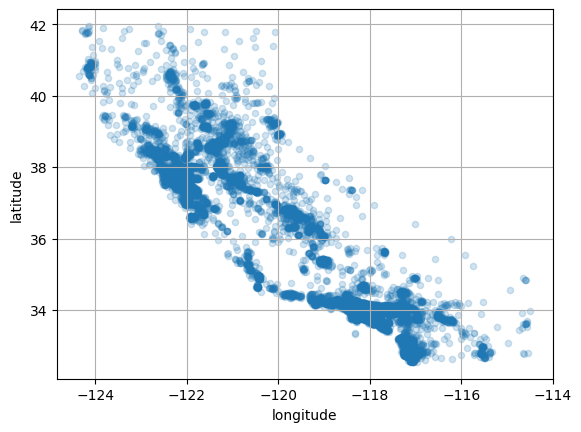

In [31]:
# visualizing all the districts on the dataset
housing.plot(kind="scatter", x="longitude", y="latitude", grid=True, alpha=.2) # alpha=.2 highlights better density on the data
plt.show()